In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url, header=0, names=['Month', 'Passengers'])

print("First 5 row:")
print(df.head())

print("\nData Types:\n", df.dtypes)



First 5 row:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Data Types:
 Month         object
Passengers     int64
dtype: object


In [45]:
if 'Month' in df.columns:
    df['Month'] = pd.to_datetime(df['Month'])
    df = df.set_index('Month')

print("First 5 row:")
print(df.head())

print("\nDate range:")
print("Starting date:", df.index.min())
print("Final date:", df.index.max())

print("\nIs there any null values?")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Outlier detection using IQR
Q1 = df['Passengers'].quantile(0.25)
Q3 = df['Passengers'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Passengers'] < Q1 - 1.5 * IQR) | (df['Passengers'] > Q3 + 1.5 * IQR)]
print(f"\nNumber of outliers detected (IQR method): {len(outliers)}")
print(outliers)

First 5 row:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Date range:
Starting date: 1949-01-01 00:00:00
Final date: 1960-12-01 00:00:00

Is there any null values?
Passengers    0
dtype: int64

Duplicate rows:
26

Number of outliers detected (IQR method): 0
Empty DataFrame
Columns: [Passengers]
Index: []


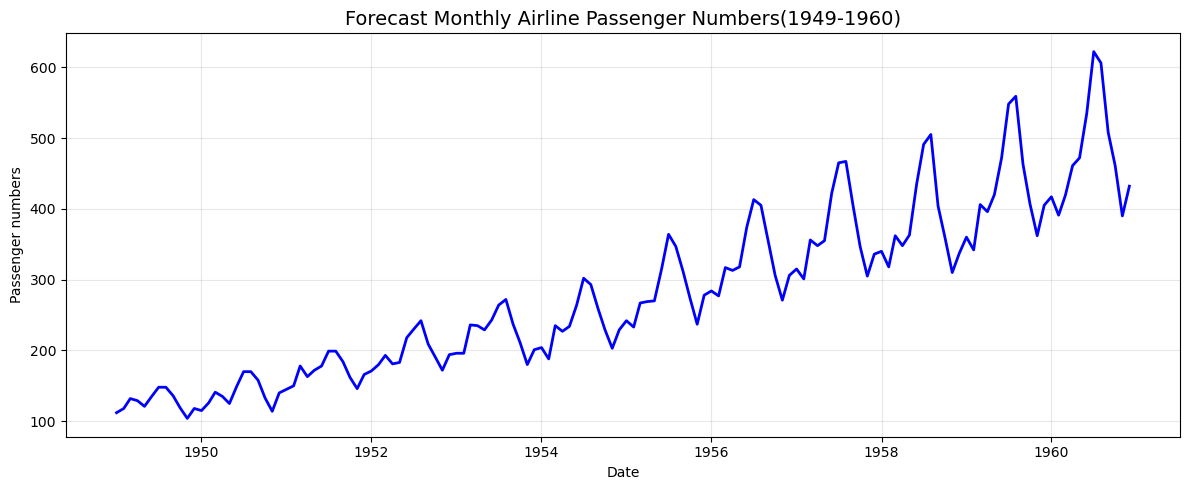

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Passengers'], color='blue', linewidth=2)
plt.title('Forecast Monthly Airline Passenger Numbers(1949-1960)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Passenger numbers')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
#CHAPTER 3.1
print("\nDescriptive Statistics ")
print(f"Skewness:  {df['Passengers'].skew():.4f}")
print(f"Kurtosis:  {df['Passengers'].kurt():.4f}")
print(f"Medyan:    {df['Passengers'].median():.1f}")
print(f"variance:  {df['Passengers'].var():.1f}")
print(f"Mean:      {df['Passengers'].mean():.1f}")




Descriptive Statistics 
Skewness:  0.5832
Kurtosis:  -0.3649
Medyan:    265.5
variance:  14391.9
Mean:      280.3


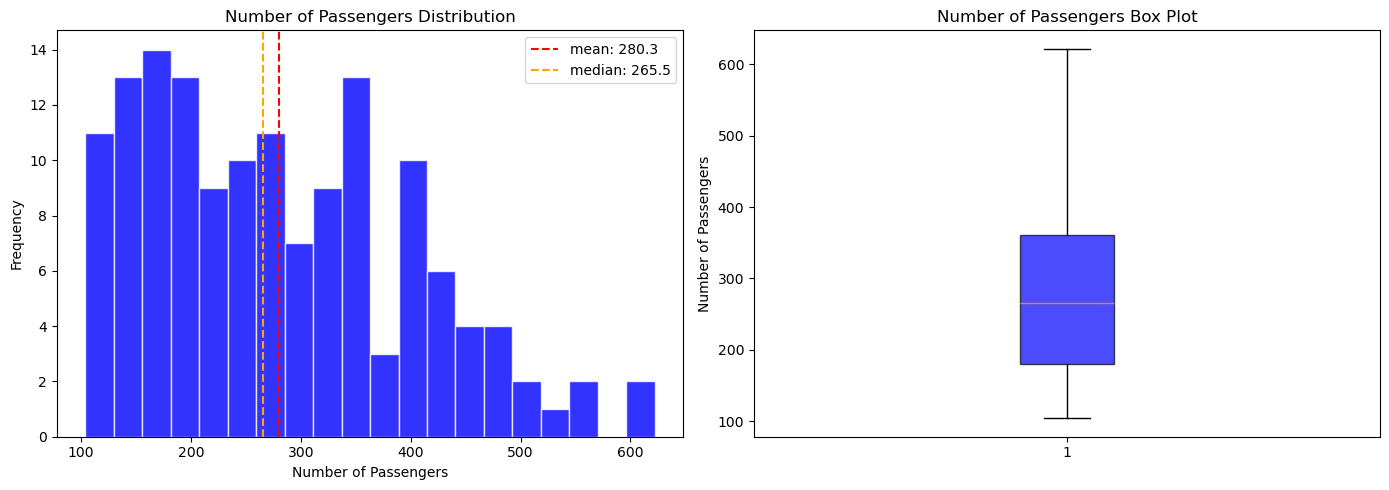

In [48]:
#CHAPTER 3 
#EDA(Exploratory Data Analysis)
# Chapter 3.3 Box Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Passengers'], bins=20, color='blue',edgecolor='white', alpha=0.8)
axes[0].axvline(df['Passengers'].mean(), color='red',linestyle='--', label=f"mean: {df['Passengers'].mean():.1f}")
axes[0].axvline(df['Passengers'].median(), color='orange',linestyle='--', label=f"median: {df['Passengers'].median():.1f}")
axes[0].set_title('Number of Passengers Distribution')
axes[0].set_xlabel('Number of Passengers')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box Plot
axes[1].boxplot(df['Passengers'], patch_artist=True, boxprops=dict(facecolor='blue', alpha=0.7))
axes[1].set_title('Number of Passengers Box Plot')
axes[1].set_ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

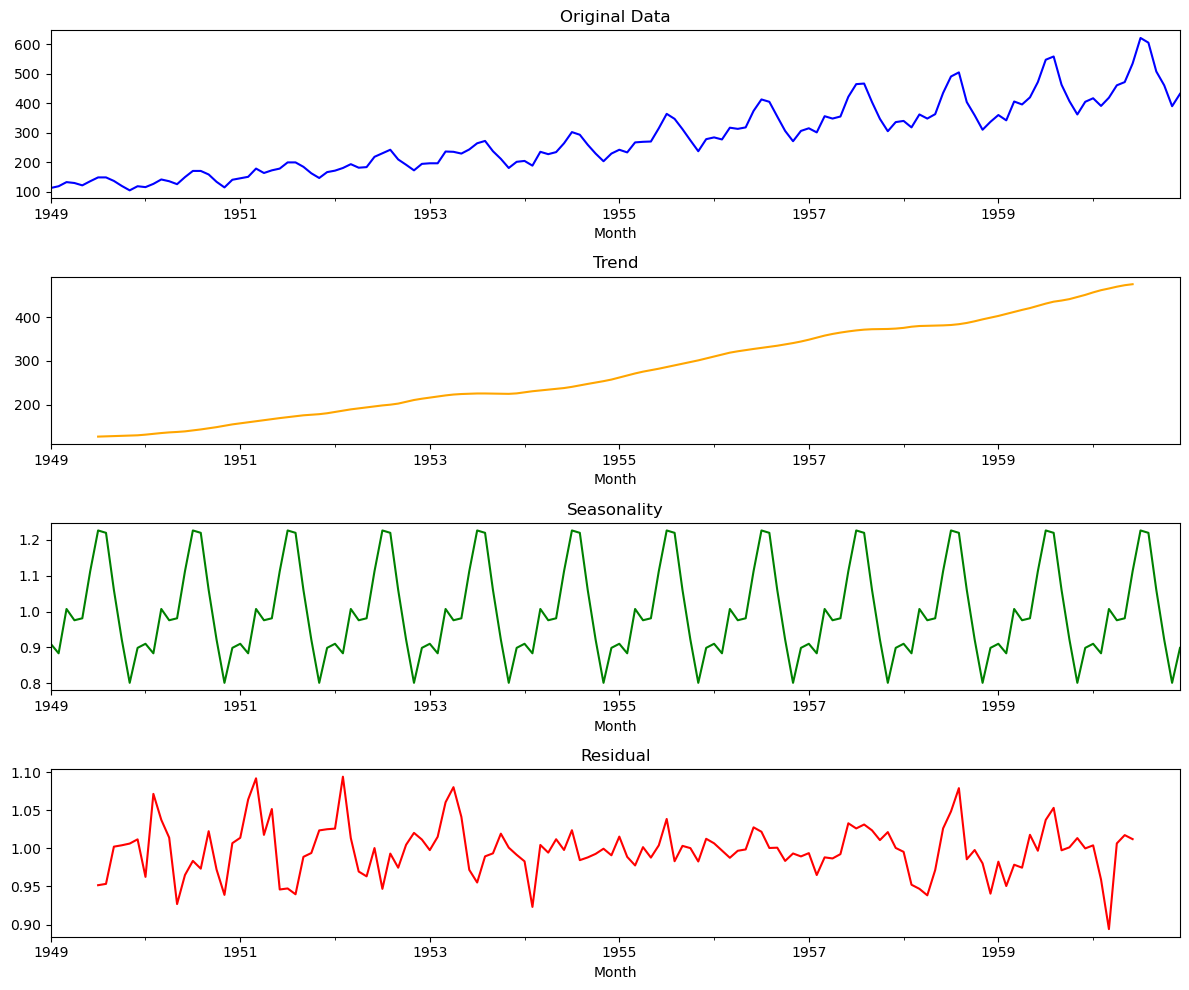

In [49]:
#CHAPTER 3 
#CHAPTER 3.2 Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Multiplicative kullanıyoruz çünkü dalgalanmalar zamanla büyüyor

decomposition = seasonal_decompose(df['Passengers'],model='multiplicative',period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], title='Original Data', color='blue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')

plt.tight_layout()
plt.show()

In [50]:
# Chapter 3
# Chapter 3.2

#Raporda seasonality için bu rakamlar kullanılacak
# Mevsimsel etkileri alıyoruz
seasonal_factors = decomposition.seasonal[:12]

# DataFrame'i oluştururken sütun isimlerini netleştiriyoruz
seasonal_df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Seasonal_Effect': seasonal_factors.values
})

# Sütun isimlerini güncelledik, şimdi .loc içinde 'Seasonal_Effect' kullanacağız
print("=== Monthly Seasonal Effects ===")
print(seasonal_df.to_string(index=False))

# Sütun ismi artık 'Seasonal_Effect' olduğu için burada da aynı ismi kullanmalıyız
busiest = seasonal_df.loc[seasonal_df['Seasonal_Effect'].idxmax(), 'Month']
calmest = seasonal_df.loc[seasonal_df['Seasonal_Effect'].idxmin(), 'Month']

print("\nThe busiest month:", busiest)
print("The calmest month:", calmest)

=== Monthly Seasonal Effects ===
Month  Seasonal_Effect
  Jan         0.910230
  Feb         0.883625
  Mar         1.007366
  Apr         0.975906
  May         0.981378
  Jun         1.112776
  Jul         1.226556
  Aug         1.219911
  Sep         1.060492
  Oct         0.921757
  Nov         0.801178
  Dec         0.898824

The busiest month: Jul
The calmest month: Nov


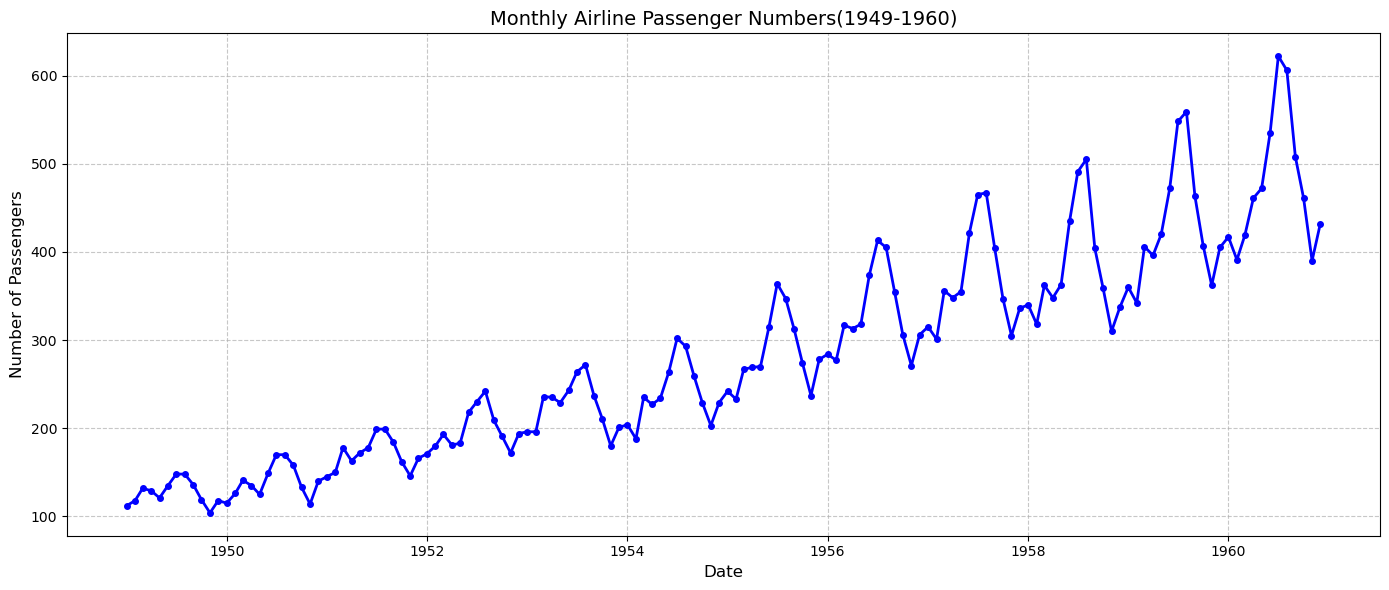

In [51]:
# Chapter 3
# Chapter 3.3 Line Plot

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Passengers'], marker='o', linestyle='-', color='blue', linewidth=2, markersize=4)

plt.title('Monthly Airline Passenger Numbers(1949-1960)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Raporunuza eklerken bu grafik için şu analizi yazabilirsiniz:
plt.tight_layout()
plt.show()

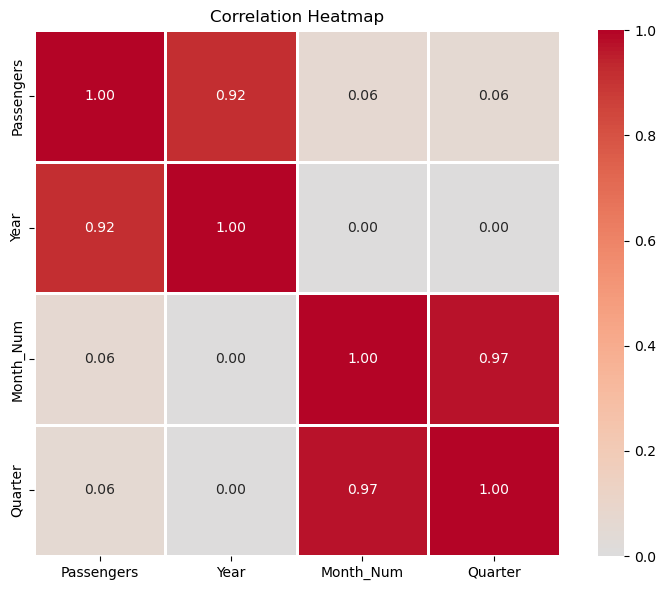

            Passengers          Year     Month_Num       Quarter
Passengers    1.000000  9.218238e-01  6.364920e-02  6.149002e-02
Year          0.921824  1.000000e+00  1.344515e-14  1.377542e-14
Month_Num     0.063649  1.344515e-14  1.000000e+00  9.716254e-01
Quarter       0.061490  1.377542e-14  9.716254e-01  1.000000e+00


In [52]:
# Chapter 3
# Chapter 3.3 Correlation Heatmap
df_corr = df.copy()
df_corr['Year']  = df_corr.index.year
df_corr['Month_Num'] = df_corr.index.month
df_corr['Quarter'] = df_corr.index.quarter

# Korelasyon matrisi
plt.figure(figsize=(8, 6))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(corr_matrix)


Train seti: 115 ay (1949-01 → 1958-07)
Test seti:  29 ay (1958-08 → 1960-12)


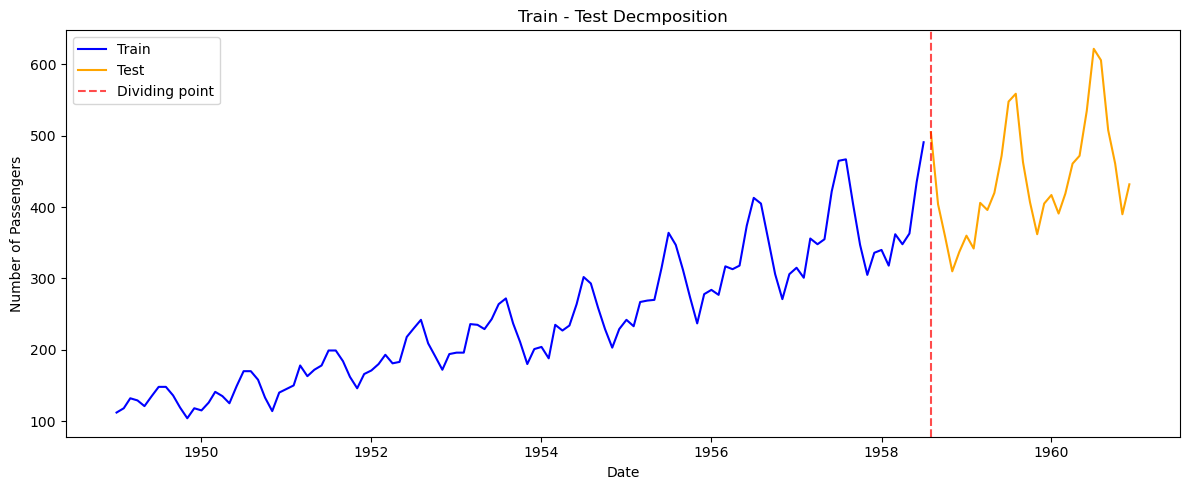

In [53]:
#Chapter 2
#Chapter 2.4 Data Splitting

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f"Train seti: {len(train)} ay ({train.index[0].strftime('%Y-%m')} → {train.index[-1].strftime('%Y-%m')})")
print(f"Test seti:  {len(test)} ay ({test.index[0].strftime('%Y-%m')} → {test.index[-1].strftime('%Y-%m')})")

# Görselleştir
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.axvline(x=test.index[0], color='red', linestyle='--', alpha=0.7, label='Dividing point')
plt.title('Train - Test Decmposition')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
#Chapter 4 
#Chapter 4.1 ARIMA
# Model Explanation (p, d, q parameters)
# Implementation (Code + hyperparameter tuning)

from pmdarima import auto_arima

arima_model = auto_arima(
    train['Passengers'],
    seasonal=True,     
    m=12,               
    stepwise=True,      
    trace=True,         
    suppress_warnings=True
)

print("\nThe Best Model")
print(arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=757.714, Time=0.90 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=757.826, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=755.750, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=756.380, Time=0.17 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=755.499, Time=0.03 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=755.982, Time=0.17 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=757.649, Time=0.24 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=756.771, Time=0.03 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=756.022, Time=0.04 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=756.011, Time=0.04 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=757.976, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=757.438, Time=0.06 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.892 seconds

The Best Model
                                     SARIMAX Results                   

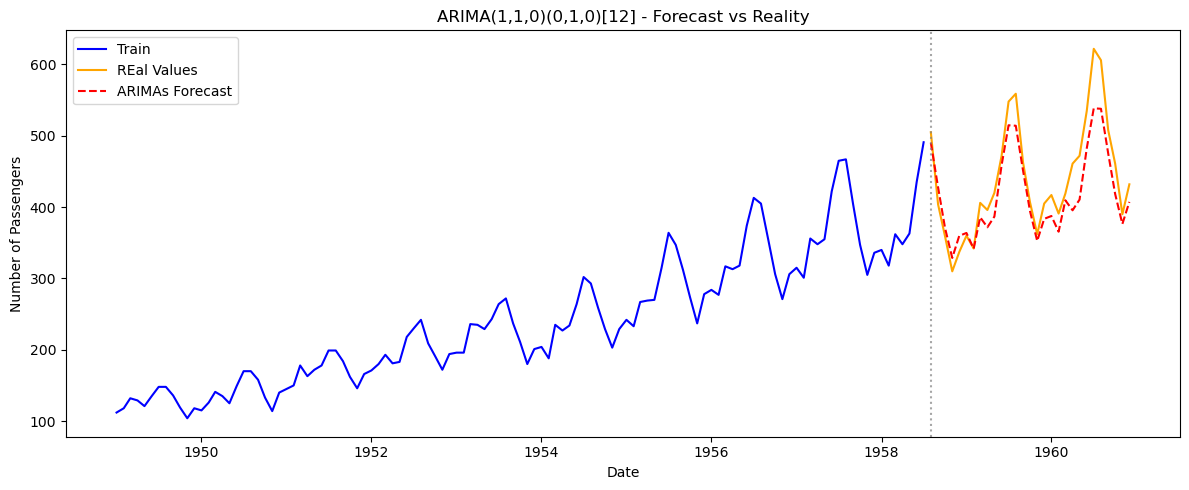

In [55]:
#Chapter 4
#Chapter 4.1 ARIMA
#Forecast Visualization (Plot predictions vs. actual).
arima_forecast = arima_model.predict(n_periods=len(test))

arima_pred = pd.Series(arima_forecast, index=test.index)


plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Passengers'], 
         label='Train', color='blue')
plt.plot(test.index, test['Passengers'], 
         label='REal Values', color='orange')
plt.plot(test.index, arima_pred, 
         label='ARIMAs Forecast', color='red', linestyle='--')
plt.axvline(x=test.index[0], color='gray', 
            linestyle=':', alpha=0.7)
plt.title('ARIMA(1,1,0)(0,1,0)[12] - Forecast vs Reality')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()


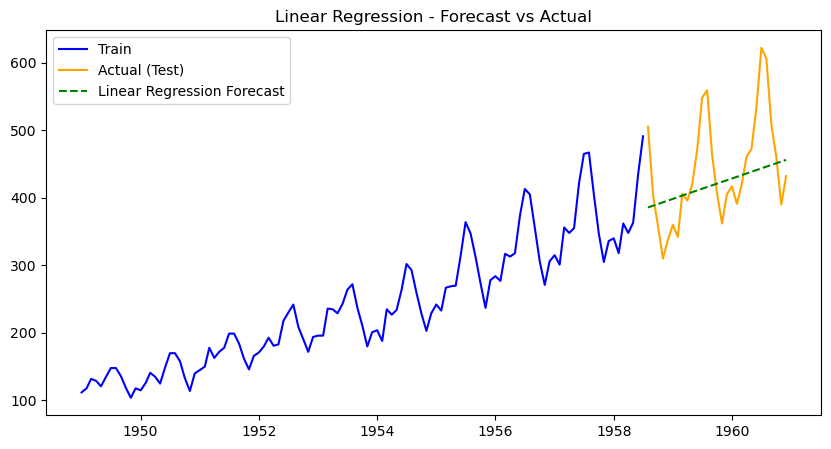

In [56]:
#Chapter 4
#Chapter 4.2 Regression-Based
#Chapter 4.2.1 Linear Regression
from sklearn.linear_model import LinearRegression

# Create time index for full df, train, and test
df['Time'] = np.arange(len(df))
train = train.copy()
test = test.copy()
train.loc[:, 'Time'] = np.arange(len(train))
test.loc[:, 'Time'] = np.arange(len(train), len(df))

X_train = train[['Time']]
y_train = train['Passengers']
X_test = test[['Time']]
y_test = test['Passengers']

# Fit on train only
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict on test
lin_pred = pd.Series(lin_model.predict(X_test), index=test.index)
df['Lin_Trend'] = lin_model.predict(df[['Time']])

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Actual (Test)', color='orange')
plt.plot(test.index, lin_pred, label='Linear Regression Forecast', linestyle='--', color='green')
plt.legend()
plt.title('Linear Regression - Forecast vs Actual')
plt.show()

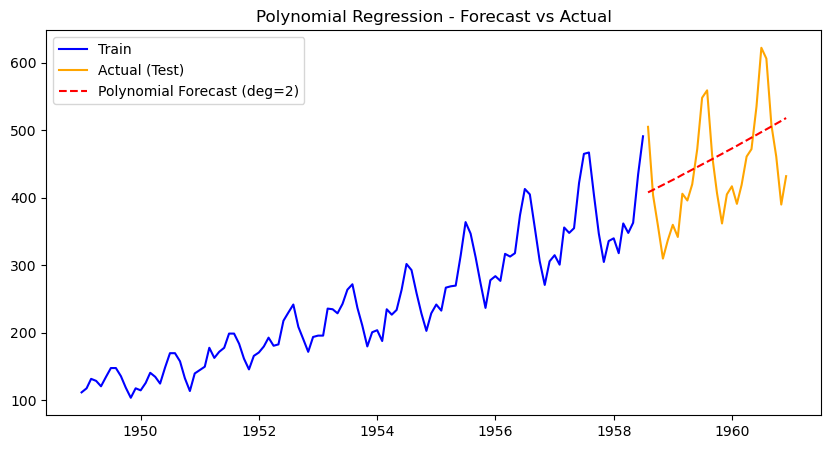

In [57]:
#Chapter 4
#Chapter 4.2 Regression-Based
#Chapter 4.2.2 Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on test
poly_pred = pd.Series(poly_model.predict(X_test_poly), index=test.index)
df['Poly_Trend'] = poly_model.predict(poly.transform(df[['Time']]))

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Actual (Test)', color='orange')
plt.plot(test.index, poly_pred, label='Polynomial Forecast (deg=2)', linestyle='--', color='red')
plt.legend()
plt.title('Polynomial Regression - Forecast vs Actual')
plt.show()

In [58]:
#Chapter 4
#Chapter 4.2 Regression-Based
#Chapter 4.2.3 Feature Importance
# Feature Importance for Linear Regression
print(f"Linear Model Coefficient (Slope): {lin_model.coef_[0]:.4f}")
print("Interpretation: On average, passengers increase by this amount each month.")

# For Polynomial Regression
print(f"Polynomial Model Coefficients (Intercept, Coeff_x, Coeff_x^2): {poly_model.coef_}")

Linear Model Coefficient (Slope): 2.5136
Interpretation: On average, passengers increase by this amount each month.
Polynomial Model Coefficients (Intercept, Coeff_x, Coeff_x^2): [0.         1.39249723 0.00983399]


In [59]:
#Chapter 5
#Chapter 5.1 Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_test = test['Passengers']

# ARIMA metrics (on test set)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
arima_mape = mape(y_test, arima_pred)
arima_r2   = r2_score(y_test, arima_pred)

# Linear Regression metrics (on test set)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
lin_mape = mape(y_test, lin_pred)
lin_r2   = r2_score(y_test, lin_pred)

# Polynomial Regression metrics (on test set)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_mape = mape(y_test, poly_pred)
poly_r2   = r2_score(y_test, poly_pred)

# Comparison Table
results = pd.DataFrame({
    'Model':  ['ARIMA', 'Linear Regression', 'Polynomial Regression'],
    'RMSE':   [round(arima_rmse, 2), round(lin_rmse, 2), round(poly_rmse, 2)],
    'MAPE (%)': [round(arima_mape, 2), round(lin_mape, 2), round(poly_mape, 2)],
    'R²':     [round(arima_r2, 4), round(lin_r2, 4), round(poly_r2, 4)]
})

print("=== Model Comparison (on Test Set) ===")
print(results.to_string(index=False))

=== Model Comparison (on Test Set) ===
                Model  RMSE  MAPE (%)     R²
                ARIMA 35.08      6.12 0.7984
    Linear Regression 73.80     12.07 0.1077
Polynomial Regression 73.10     14.91 0.1246
